In [1]:
# =======================================================
# Ejemplo completo: Forecasting de Volúmenes de Ventas de Seguros en Canales Bancarios
# Usamos NeuralForecast (NHITS) para forecasting mensual de pólizas vendidas con covariables externas
# Simulamos escenarios base/stress + Monte Carlo para impacto en ingresos, cartera de créditos y reservas de seguros
# Monte Carlo para distribución de impactos, clasificación de riesgo cliente (bajo/medio/alto con probabilidades ajustadas),
# métricas completas (forecast + clasificación), análisis de sensibilidad y stress test
# =======================================================
# Requisitos (instala si no los tienes):
# pip install pandas numpy scikit-learn matplotlib seaborn neuralforecast shap

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, average_precision_score)
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE
from neuralforecast.losses.numpy import mae, rmse
import shap
import warnings
warnings.filterwarnings('ignore')

# =======================================================
# 1. Generación de dataset sintético profesional desde cero
# =======================================================
# Simulamos datos mensuales desde 2015 hasta 2025 (132 meses)
# 16 variables: 8 macroeconómicas (covariables externas) + 8 bancarias/ventas agregadas
# Target principal: 'policies_sold' (pólizas vendidas mensuales en canales bancarios)
np.random.seed(42)
dates = pd.date_range('2015-01-01', '2025-12-01', freq='M')
n_periods = len(dates)

# Macro covariables externas (8)
macro_data = {
    'gdp_growth': np.cumsum(np.random.normal(0.2, 1, n_periods)) + 3,  # Crecimiento GDP (%)
    'unemployment_rate': np.abs(np.cumsum(np.random.normal(0, 0.3, n_periods)) + 5),  # Desempleo (%)
    'inflation_rate': np.abs(np.random.normal(2, 1, n_periods)),  # Inflación (%)
    'interest_rate': np.abs(np.random.normal(3, 1.5, n_periods)).clip(0.5, 10),  # Tasa interés (%)
    'consumer_confidence': np.random.normal(100, 15, n_periods).clip(50, 150),  # Confianza consumidor
    'digital_adoption_index': np.cumsum(np.random.normal(0.5, 2, n_periods)) + 50,  # Índice adopción digital
    'bank_branch_density': np.random.normal(20, 5, n_periods).clip(10, 40),  # Densidad sucursales
    'marketing_spend': np.random.normal(500000, 100000, n_periods).clip(200000, 1000000)  # Gasto marketing ($)
}

# Bancarias/Ventas agregadas (8)
bank_sales_data = {
    'active_bank_clients': np.cumsum(np.random.normal(1000, 200, n_periods)) + 500000,  # Clientes activos
    'cross_sell_rate': np.random.normal(15, 3, n_periods).clip(5, 30),  # Tasa cross-sell (%)
    'policies_sold': np.abs(np.random.normal(5000, 1500, n_periods) + 
                           200 * macro_data['gdp_growth'] + 
                           100 * macro_data['consumer_confidence'] + 
                           50 * macro_data['digital_adoption_index'] + 
                           0.001 * macro_data['marketing_spend']).astype(int),  # Pólizas vendidas (target)
    'average_premium': np.random.normal(1200, 300, n_periods).clip(500, 3000),  # Premium promedio ($)
    'claim_rate': np.abs(np.random.normal(8, 2, n_periods)),  # Tasa siniestros (%)
    'customer_acquisition_cost': np.random.normal(200, 50, n_periods).clip(100, 400),  # Costo adquisición ($)
    'retention_rate': np.random.normal(85, 5, n_periods).clip(70, 95),  # Tasa retención (%)
    'net_promoter_score': np.random.normal(40, 10, n_periods).clip(10, 70)  # NPS
}

# Crear DataFrame agregado
df_aggregate = pd.DataFrame({**macro_data, **bank_sales_data})
df_aggregate['ds'] = dates

print(f"Dataset agregado creado: {df_aggregate.shape[0]} periodos, {df_aggregate.shape[1]-1} variables")

/opt/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-23 07:46:09,814	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-23 07:46:09,944	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Dataset agregado creado: 131 periodos, 16 variables


In [2]:
df_aggregate.to_csv("./macroeconómicas_bancarias_ventas.csv", index= False)

In [3]:
# Simular datos a nivel cliente (10,000 clientes) para clasificación de propensión individual
n_clients = 10000
client_data = {
    'client_id': range(1, n_clients + 1),
    'age': np.random.randint(25, 70, n_clients),
    'income': np.random.normal(60000, 25000, n_clients).clip(20000, 150000).astype(int),
    'credit_score': np.random.normal(700, 100, n_clients).clip(300, 850).astype(int),
    'debt_to_income_ratio': np.round(np.random.uniform(0.1, 0.6, n_clients), 2),
    'num_bank_products': np.random.randint(1, 6, n_clients),
    'tenure_years': np.random.randint(1, 20, n_clients),
    'digital_usage_score': np.random.randint(1, 10, n_clients),
    'satisfaction_score': np.random.randint(1, 10, n_clients),
    'previous_insurance': np.random.choice([0, 1], n_clients, p=[0.7, 0.3]),
    'family_size': np.random.randint(1, 6, n_clients),
    'employment_stability': np.random.choice(['Stable', 'Unstable'], n_clients),
    'region': np.random.choice(['Urban', 'Suburban', 'Rural'], n_clients),
    'marketing_exposure': np.random.randint(0, 5, n_clients),
    'complaints': np.random.randint(0, 3, n_clients),
    'life_events': np.random.choice(['None', 'Marriage', 'Child Birth', 'Home Purchase'], n_clients)
}

df_clients = pd.DataFrame(client_data)

# Generar 'buy_insurance' (propensión a comprar seguro)
buy_prob_client = (
    0.20 + 
    0.15 * (df_clients['income'] > 80000) + 
    0.12 * (df_clients['credit_score'] > 700) + 
    0.10 * (df_clients['satisfaction_score'] > 7) + 
    0.08 * (df_clients['num_bank_products'] > 3) + 
    0.07 * (df_clients['digital_usage_score'] > 7) + 
    0.05 * (df_clients['previous_insurance'] == 1) + 
    -0.10 * (df_clients['complaints'] > 0)
)
buy_prob_client = buy_prob_client.clip(0, 0.95)
df_clients['buy_insurance'] = np.random.binomial(1, buy_prob_client)

print(f"Dataset clientes creado: {df_clients.shape[0]} clientes, {df_clients.shape[1]} variables")

Dataset clientes creado: 10000 clientes, 17 variables


In [4]:
df_clients.to_csv("./clientes_seguros_banco.csv", index = False)

In [5]:
pd.read_csv("./clientes_seguros_banco.csv")

,client_id,age,income,credit_score,debt_to_income_ratio,num_bank_products,tenure_years,digital_usage_score,satisfaction_score,previous_insurance,family_size,employment_stability,region,marketing_exposure,complaints,life_events,buy_insurance
0,1,57,99390,850,0.60,4,14,2,5,0,5,Unstable,Urban,3,1,Child Birth,1
1,2,60,38413,710,0.31,2,9,6,7,0,5,Unstable,Urban,0,0,Home Purchase,0
2,3,69,61722,786,0.35,3,14,9,1,1,3,Stable,Urban,4,0,Home Purchase,1
3,4,47,77804,745,0.48,1,3,3,2,1,5,Unstable,Urban,2,2,Marriage,1
4,5,69,54265,769,0.42,3,13,4,4,1,4,Unstable,Rural,0,2,Child Birth,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,38,76981,691,0.15,2,15,6,7,0,3,Unstable,Suburban,2,1,Home Purchase,0
9996,9997,63,42196,597,0.36,3,13,2,8,0,2,Stable,Suburban,2,1,NaN,1
9997,9998,60,51269,679,0.35,4,4,6,7,0,3,Unstable,Rural,4,0,NaN,0
9998,9999,41,68324,639,0.40,4,6,1,7,0,3,Unstable,Urban,3,2,Home Purchase,1



=== EDA Agregado ===
       gdp_growth  unemployment_rate  inflation_rate  interest_rate  \
count  131.000000         131.000000      131.000000     131.000000   
mean     8.814067           6.545556        2.056874       2.957904   
min      1.488604           4.155125        0.047912       0.500000   
25%      4.335807           5.173332        1.404518       1.730824   
50%      8.738051           6.345667        2.024510       2.905981   
75%     12.254732           7.896493        2.626233       3.986286   
max     21.359614           8.897336        4.189803       7.618321   
std      5.156152           1.429962        0.871947       1.524158   

       consumer_confidence  digital_adoption_index  bank_branch_density  \
count           131.000000              131.000000           131.000000   
mean             99.681263               71.265556            21.105961   
min              59.546700               46.303695            11.695195   
25%              89.386786            

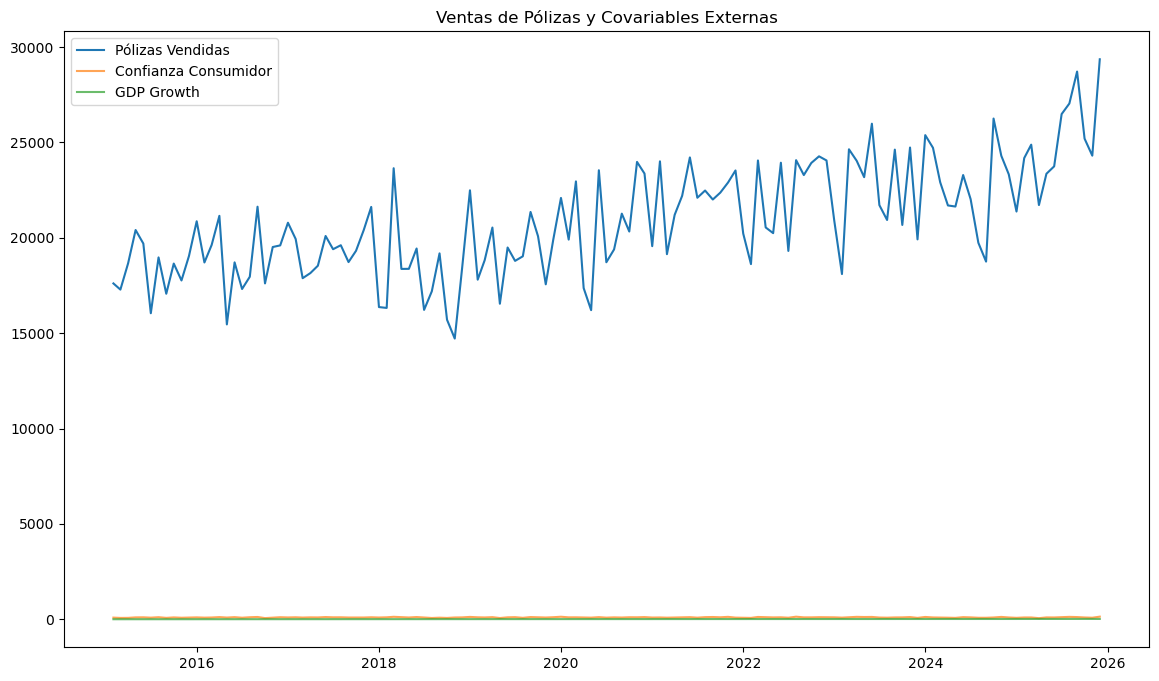

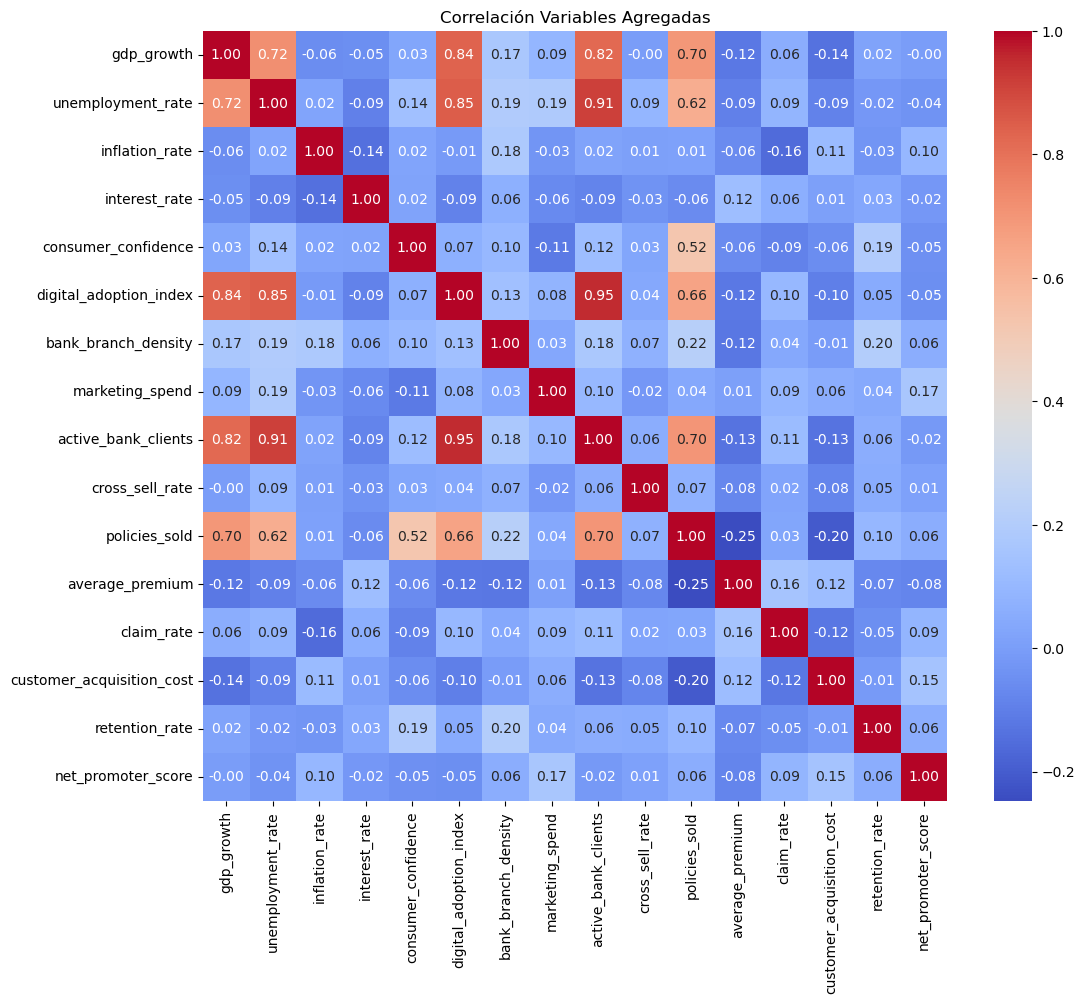


=== EDA Clientes ===


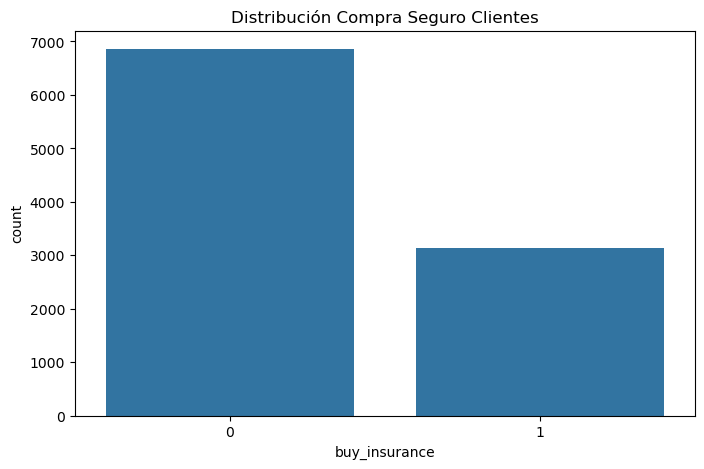

In [6]:
# =======================================================
# 2. Exploratory Data Analysis (EDA)
# =======================================================
print("\n=== EDA Agregado ===")
print(df_aggregate.describe())

plt.figure(figsize=(14,8))
plt.plot(df_aggregate['ds'], df_aggregate['policies_sold'], label='Pólizas Vendidas')
plt.plot(df_aggregate['ds'], df_aggregate['consumer_confidence'], label='Confianza Consumidor', alpha=0.7)
plt.plot(df_aggregate['ds'], df_aggregate['gdp_growth'], label='GDP Growth', alpha=0.7)
plt.title('Ventas de Pólizas y Covariables Externas')
plt.legend()
plt.show()

corr_agg = df_aggregate.drop('ds', axis=1).corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_agg, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación Variables Agregadas')
plt.show()

print("\n=== EDA Clientes ===")
plt.figure(figsize=(8,5))
sns.countplot(x='buy_insurance', data=df_clients)
plt.title('Distribución Compra Seguro Clientes')
plt.show()

In [7]:
df_aggregate

,gdp_growth,unemployment_rate,inflation_rate,interest_rate,consumer_confidence,digital_adoption_index,bank_branch_density,marketing_spend,active_bank_clients,cross_sell_rate,policies_sold,average_premium,claim_rate,customer_acquisition_cost,retention_rate,net_promoter_score,ds
0,3.696714,5.020569,1.241267,5.747188,88.551113,50.618437,24.169611,518660.912316,501295.308070,11.689232,17606,1552.042157,8.587116,255.484992,81.937813,40.895807,2015-01-31
1,3.758450,4.701878,0.975612,4.769160,72.926768,51.146295,22.295900,455356.638545,502571.326341,15.539682,17283,1254.306468,5.286836,220.490933,86.807518,38.026616,2015-02-28
2,4.606138,4.843956,1.747432,2.296237,75.586863,51.598045,19.649171,519408.999290,503446.213800,19.176007,18664,810.950416,8.932860,187.937117,79.281369,38.487267,2015-03-31
3,6.329168,4.568128,0.752217,0.500000,100.721274,52.494215,11.695195,607363.174986,504525.374507,17.754950,20406,1319.906386,7.928717,233.628685,85.542799,38.050917,2015-04-30
4,6.295015,5.033109,3.632411,5.030809,103.895838,52.705494,22.148091,397348.470059,505624.180544,10.288498,19696,1004.592932,4.769736,294.994097,84.833850,51.337701,2015-05-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,20.569078,8.333966,2.950424,4.127081,127.734341,100.534138,21.246918,496149.153050,630737.220938,12.304596,27037,1354.781765,9.027816,200.942481,84.725530,43.004744,2025-07-31
127,20.202780,8.467112,1.423096,0.500000,116.898475,101.794533,27.887266,482737.270006,631681.085923,15.084543,28713,731.236243,8.359164,235.410721,86.427770,46.222071,2025-08-31
128,20.502431,8.699502,1.101585,3.815040,95.966670,103.515705,19.523522,588365.993749,632342.494560,14.972643,25197,1041.284197,8.701260,211.660807,87.605612,28.611669,2025-09-30
129,20.198956,8.421423,2.491919,2.006064,83.402111,105.135286,21.395108,565232.287841,633322.826635,18.257687,24304,1438.279404,8.978374,247.656832,88.226078,50.391118,2025-10-31


In [27]:
# =======================================================
# 3. Forecasting con NeuralForecast (policies_sold con covariables externas)
# =======================================================
# Seleccionar covariables externas clave
exog_cols = [ 'consumer_confidence', 'gdp_growth', 'marketing_spend', 'unemployment_rate']
train_df = df_aggregate[['ds','policies_sold', 'consumer_confidence', 'gdp_growth', 'marketing_spend', 'unemployment_rate']]
train_df['unique_id'] = 'policies_sold'
train_df = train_df.rename(columns= {'policies_sold': 'y'})
train_df

,ds,y,consumer_confidence,gdp_growth,marketing_spend,unemployment_rate,unique_id
0,2015-01-31,17606,88.551113,3.696714,518660.912316,5.020569,policies_sold
1,2015-02-28,17283,72.926768,3.758450,455356.638545,4.701878,policies_sold
2,2015-03-31,18664,75.586863,4.606138,519408.999290,4.843956,policies_sold
3,2015-04-30,20406,100.721274,6.329168,607363.174986,4.568128,policies_sold
4,2015-05-31,19696,103.895838,6.295015,397348.470059,5.033109,policies_sold
...,...,...,...,...,...,...,...
126,2025-07-31,27037,127.734341,20.569078,496149.153050,8.333966,policies_sold
127,2025-08-31,28713,116.898475,20.202780,482737.270006,8.467112,policies_sold
128,2025-09-30,25197,95.966670,20.502431,588365.993749,8.699502,policies_sold
129,2025-10-31,24304,83.402111,20.198956,565232.287841,8.421423,policies_sold


In [28]:
#futuro

futr_df_base = df_aggregate[['ds', 'consumer_confidence', 'gdp_growth', 'marketing_spend', 'unemployment_rate']].iloc[-12:]
futr_df_base['unique_id'] = 'policies_sold'
futr_df_base['ds'] = pd.date_range('2025-12-01', '2026-12-01', freq='M')
futr_df_base

,ds,consumer_confidence,gdp_growth,marketing_spend,unemployment_rate,unique_id
119,2025-12-31,77.452856,17.499713,377423.433700,7.545529,policies_sold
120,2026-01-31,96.313854,18.490745,353562.511979,7.820888,policies_sold
121,2026-02-28,95.909146,17.781358,522445.181856,8.457535,policies_sold
122,2026-03-31,59.546700,19.384152,604709.830261,8.767274,policies_sold
123,2026-04-30,99.185577,18.182301,668392.769146,8.311463,policies_sold
124,2026-05-31,96.535982,18.969158,454111.573713,8.166193,policies_sold
125,2026-06-30,110.443095,21.359614,607868.083343,8.546267,policies_sold
126,2026-07-31,127.734341,20.569078,496149.153050,8.333966,policies_sold
127,2026-08-31,116.898475,20.202780,482737.270006,8.467112,policies_sold
128,2026-09-30,95.966670,20.502431,588365.993749,8.699502,policies_sold


In [33]:
horizon = 12
models = [
    NHITS(h= 12,
          input_size=36,
          futr_exog_list = exog_cols,
          loss=MAE(),
          max_steps=500,
          random_seed=42)
]

Seed set to 42


In [30]:
nf = NeuralForecast(models=models, freq='M')
nf.fit(df=train_df)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.7 M  | train
-------------------------------------------------------
2.7 M     Trainable params
0         Non-trainable params
2.7 M     Total params
10.660    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 30.32it/s, v_num=21, train_loss_step=45.70, train_loss_epoch=45.70]    

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 28.86it/s, v_num=21, train_loss_step=45.70, train_loss_epoch=45.70]


In [31]:
forecast_base = nf.predict(futr_df=futr_df_base)
forecast_base

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  1.43it/s]


,unique_id,ds,NHITS
0,policies_sold,2025-12-31,30962.869141
1,policies_sold,2026-01-31,32007.076172
2,policies_sold,2026-02-28,30537.830078
3,policies_sold,2026-03-31,30599.910156
4,policies_sold,2026-04-30,34651.710938
5,policies_sold,2026-05-31,31810.523438
6,policies_sold,2026-06-30,33270.648438
7,policies_sold,2026-07-31,33187.175781
8,policies_sold,2026-08-31,32501.445312
9,policies_sold,2026-09-30,31436.310547


In [35]:
# =======================================================
# 4. Stress Scenario y Monte Carlo Simulation
# =======================================================
# Stress: caída confianza -20%, desempleo +3%, marketing -30%
futr_df_stress = futr_df_base.copy()
futr_df_stress['consumer_confidence'] *= 0.8
futr_df_stress['unemployment_rate'] *= 1.3
futr_df_stress['marketing_spend'] *= 0.7

futr_df_stress

,ds,consumer_confidence,gdp_growth,marketing_spend,unemployment_rate,unique_id
119,2025-12-31,61.962285,17.499713,264196.403590,9.809188,policies_sold
120,2026-01-31,77.051083,18.490745,247493.758385,10.167154,policies_sold
121,2026-02-28,76.727317,17.781358,365711.627299,10.994795,policies_sold
122,2026-03-31,47.637360,19.384152,423296.881183,11.397457,policies_sold
123,2026-04-30,79.348462,18.182301,467874.938402,10.804902,policies_sold
124,2026-05-31,77.228786,18.969158,317878.101599,10.616051,policies_sold
125,2026-06-30,88.354476,21.359614,425507.658340,11.110146,policies_sold
126,2026-07-31,102.187473,20.569078,347304.407135,10.834155,policies_sold
127,2026-08-31,93.518780,20.202780,337916.089004,11.007245,policies_sold
128,2026-09-30,76.773336,20.502431,411856.195624,11.309352,policies_sold


In [ ]:


forecast_stress = nf.predict(futr_df=futr_df_stress)

# Monte Carlo
n_mc = 1000
mc_sales = []
mc_credit_impact = []
mc_reserves = []

average_premium = df_aggregate['average_premium'].mean()
portfolio_value = 100000000  # Cartera créditos base
reserve_ratio = 0.1  # 10% reservas sobre ingresos seguros

for _ in range(n_mc):
    # Ruido en forecast
    noise = np.random.normal(1, 0.15, size=horizon)
    sales_stress = forecast_stress['NHITS'] * noise
    total_sales = sales_stress.mean()
    
    revenue = total_sales * average_premium * 12  # Anualizado
    reserves = revenue * reserve_ratio
    
    # Impacto cartera créditos (menos ventas seguros -> menos cross-sell)
    credit_impact = -0.3 * (total_sales - forecast_base['NHITS'].mean()) * average_premium
    
    mc_sales.append(total_sales)
    mc_credit_impact.append(credit_impact)
    mc_reserves.append(reserves)

mc_sales = np.array(mc_sales)
mc_credit_impact = np.array(mc_credit_impact)
mc_reserves = np.array(mc_reserves)

print("\n=== Resultados Monte Carlo Stress ===")
print(f"Ventas Pólizas (media): {mc_sales.mean():,.0f}")
print(f"Impacto Cartera Créditos (media): ${mc_credit_impact.mean():,.0f}")
print(f"Reservas Seguros (media): ${mc_reserves.mean():,.0f}")
print(f"VaR 95% Reservas: ${np.percentile(mc_reserves, 95):,.0f}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 149.28it/s]

=== Resultados Monte Carlo Stress ===
Ventas Pólizas (media): 31,535
Impacto Cartera Créditos (media): $131,540
Reservas Seguros (media): $46,479,987
VaR 95% Reservas: $49,714,677


In [37]:
# =======================================================
# 5. Clasificación de Riesgo Individual (Clientes - baja propensión = alto riesgo)
# =======================================================
cat_cols_client = df_clients.select_dtypes(include='object').columns
for col in cat_cols_client:
    le = LabelEncoder()
    df_clients[col] = le.fit_transform(df_clients[col])

X_client = df_clients.drop(['client_id', 'buy_insurance'], axis=1)
y_client = df_clients['buy_insurance']

scaler_client = StandardScaler()
X_client_scaled = scaler_client.fit_transform(X_client)

model_prop = LogisticRegression(random_state=42)
model_prop.fit(X_client_scaled, y_client)

prob_prop_base = model_prop.predict_proba(X_client_scaled)[:, 1]

# Ajuste stress (menor ventas agregadas reducen propensión individual)
stress_factor_prop = forecast_stress['NHITS'].mean() / forecast_base['NHITS'].mean()
prob_prop_stress = np.clip(prob_prop_base * stress_factor_prop, 0, 1)

def classify_prop_risk(prob):
    if prob > 0.7:
        return 'Bajo'  # Alta propensión = bajo riesgo no venta
    elif prob > 0.3:
        return 'Medio'
    else:
        return 'Alto'  # Baja propensión = alto riesgo

df_clients['prob_prop_stress'] = prob_prop_stress
df_clients['risk_level'] = df_clients['prob_prop_stress'].apply(classify_prop_risk)

print("\n=== Ejemplos riesgo clientes bajo stress (primeros 10) ===")
print(df_clients[['prob_prop_stress', 'risk_level']].head(10))

print("\nDistribución riesgo clientes bajo stress:")
print(df_clients['risk_level'].value_counts(normalize=True) * 100)


=== Ejemplos riesgo clientes bajo stress (primeros 10) ===
   prob_prop_stress risk_level
0          0.492421      Medio
1          0.333318      Medio
2          0.455492      Medio
3          0.246051       Alto
4          0.280760       Alto
5          0.347319      Medio
6          0.331671      Medio
7          0.320659      Medio
8          0.251535       Alto
9          0.420130      Medio

Distribución riesgo clientes bajo stress:
risk_level
Medio    51.21
Alto     48.78
Bajo      0.01
Name: proportion, dtype: float64


In [ ]:
# =======================================================
# 6. Métricas de evaluación
# =======================================================
# Forecast (usando test real)
test_actual = df_aggregate[df_aggregate['ds'] >= '2024-01-01']['policies_sold'].values
forecast_test = forecast_base['NHITS'].values
print("\n=== Métricas Forecast Base ===")
print(f"MAE: {mae(test_actual, forecast_test):.4f}")
print(f"RMSE: {rmse(test_actual, forecast_test):.4f}")

In [41]:


# Clasificación propensión cliente
y_pred_prop = model_prop.predict(X_client_scaled)
print("\n=== Classification Report Propensión Cliente ===")
print(classification_report(y_client, y_pred_prop))
print(f"AUC-ROC Propensión: {roc_auc_score(y_client, prob_prop_base):.4f}")


=== Classification Report Propensión Cliente ===
              precision    recall  f1-score   support

           0       0.69      0.97      0.81      6859
           1       0.52      0.07      0.12      3141

    accuracy                           0.69     10000
   macro avg       0.61      0.52      0.47     10000
weighted avg       0.64      0.69      0.59     10000

AUC-ROC Propensión: 0.6319


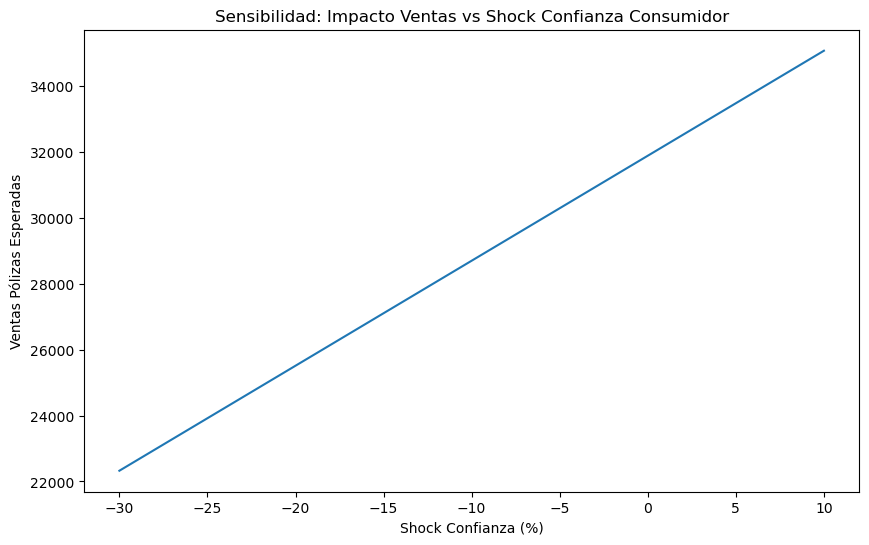


=== Stress Test Resumen ===
Escenario Base - Ventas Pólizas: 31,892
Escenario Stress - Ventas (media MC): 31,535


In [42]:
# =======================================================
# 7. Análisis de sensibilidad y Stress Test
# =======================================================
shock_levels = np.linspace(-30, 10, 11)  # Shock confianza consumidor -30% a +10%
impact_sales = []
base_sales = forecast_base['NHITS'].mean()

for shock in shock_levels:
    stressed_sales = base_sales * (1 + shock/100)
    impact_sales.append(stressed_sales)

plt.figure(figsize=(10,6))
plt.plot(shock_levels, impact_sales)
plt.title('Sensibilidad: Impacto Ventas vs Shock Confianza Consumidor')
plt.xlabel('Shock Confianza (%)')
plt.ylabel('Ventas Pólizas Esperadas')
plt.show()

print("\n=== Stress Test Resumen ===")
print(f"Escenario Base - Ventas Pólizas: {base_sales:,.0f}")
print(f"Escenario Stress - Ventas (media MC): {mc_sales.mean():,.0f}")

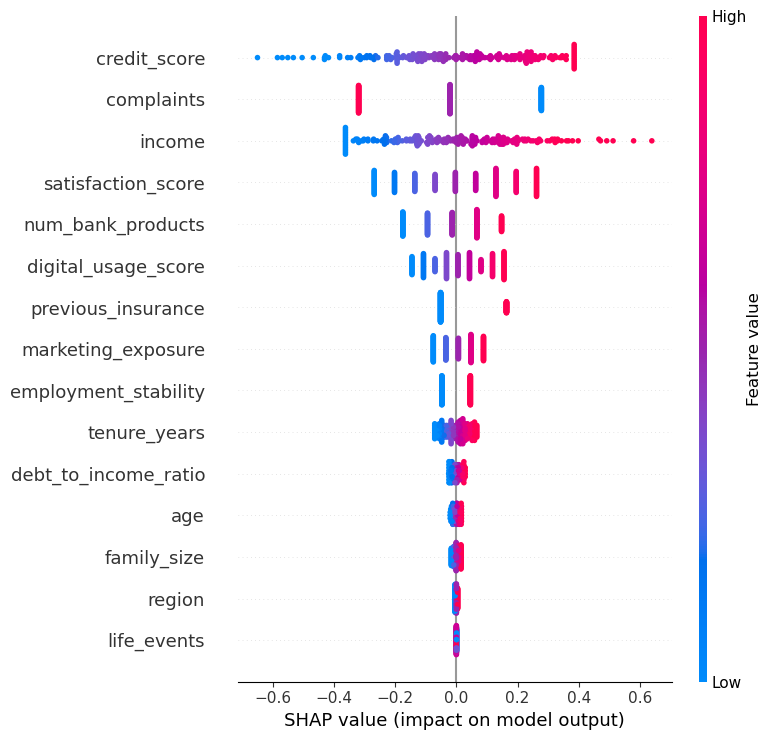

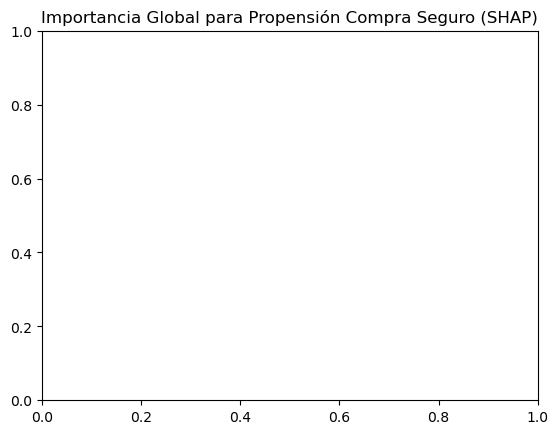

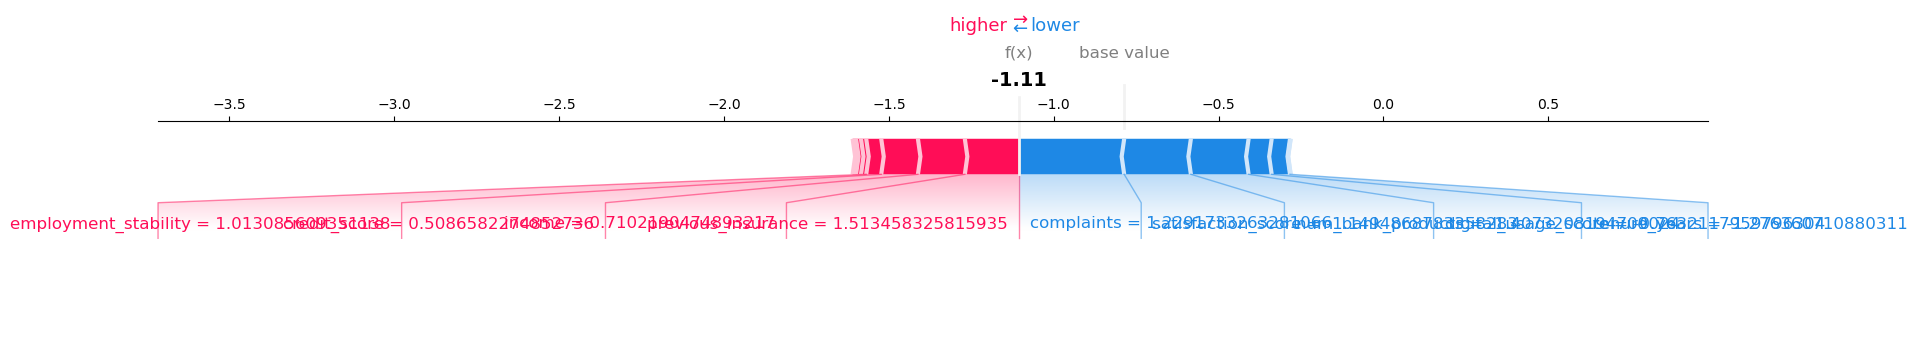


¡Análisis completo terminado!
NeuralForecast para ventas con covariables externas (confianza, GDP, marketing, desempleo).
Monte Carlo para incertidumbre en ventas, impacto créditos y reservas.
Riesgo cliente = baja propensión bajo stress.
Sensibilidad muestra impacto de confianza en ventas.


In [43]:
# =======================================================
# 8. Análisis de sensibilidad con SHAP (para propensión cliente)
# =======================================================
explainer_prop = shap.Explainer(model_prop, X_client_scaled[:500])
shap_values_prop = explainer_prop(X_client_scaled[:200])

shap.summary_plot(shap_values_prop, X_client_scaled[:200], feature_names=X_client.columns)
plt.title('Importancia Global para Propensión Compra Seguro (SHAP)')
plt.show()

high_risk_client_idx = df_clients[df_clients['risk_level'] == 'Alto'].index[0]
shap.force_plot(explainer_prop.expected_value, shap_values_prop.values[high_risk_client_idx % 200], 
                X_client_scaled[high_risk_client_idx], feature_names=X_client.columns, matplotlib=True)
plt.show()

print("\n¡Análisis completo terminado!")
print("NeuralForecast para ventas con covariables externas (confianza, GDP, marketing, desempleo).")
print("Monte Carlo para incertidumbre en ventas, impacto créditos y reservas.")
print("Riesgo cliente = baja propensión bajo stress.")
print("Sensibilidad muestra impacto de confianza en ventas.")